# Testes para construção do MLP

## 1. Rede MLP para caso XOR

### 1.1. Função de ativação e sua derivada

In [21]:
import numpy as np

# função de ativação sigmoid
def sigmoid(x):
    # Sigmoid activation function, calcula o input e retorna um valor entre 0 e 1
    return 1 / (1 + np.exp(-x))

# derivada da função sigmoid
def sigmoid_derivative(x):
    # A derivada da função sigmoid é calculada usando a própria função sigmoid
    s = sigmoid(x)
    # A derivada é dada por s * (1 - s), onde s é o valor da função sigmoid
    return s * (1 - s)


### 1.2. Função de perda (Loss)
Foi usada a função do erro quadrático médio (MSE)

In [22]:
def mse(y_true, y_pred):
    
    return np.mean(
        (y_true - y_pred) ** 2
    )

### 1.3. Inicialização dos pesos

In [23]:
# Pesos aleatorios para a camada oculta
# 2 entradas e 4 neurônios na camada oculta
W1 = np.random.randn(2,4)
# Bias é inicializado como um vetor de zeros
b1 = np.zeros((1,4))

# Pesos e bias para a camada de saída
W2 = np.random.randn(4,1)
# Bias para a camada de saída, inicializado como um vetor de zeros
b2 = np.zeros((1,1))

### 1.4. Implementação do foward

In [24]:
# Dataset XOR
# Entradas
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

# Saída esperada para a função XOR
y = np.array([
    [0],
    [1],
    [1],
    [0]
])

In [25]:
# Calculando a saída Z1 - da camada oculta
Z1 = X @ W1 + b1

# Calculando a ativação A1 usando a função sigmoid
A1 = sigmoid(Z1)

# Calculando a saída Z2 - da camada de saída
Z2 = A1 @ W2 + b2

# ativação da camada de saída
A2 = sigmoid(Z2)

In [26]:
loss = mse(y, A2)

print(loss)

0.3548202957366332


### 1.5. Backpropagation

#### 1.5.1. Cálculo do gradiente

In [28]:
learning_rate = 0.1
n_epochs = 10000

train_losses = []
train_accuracies = []

for epoch in range(n_epochs):
    # Forward pass
    # Calculando a saída Z1 - da camada oculta
    Z1 = X @ W1 + b1
    # ativação da camada oculta
    A1 = sigmoid(Z1)
    # Calculando a saída Z2 - da camada de saída
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    # Loss
    loss = mse(y, A2)
    predictions = (A2 > 0.5).astype(int)
    accuracy = np.mean(predictions == y)
    train_losses.append(loss)
    train_accuracies.append(accuracy)
    
    # Backpropagation
    dA2 = A2 - y
    # Derivada da função de ativação sigmoid para a camada de saída
    dZ2 = dA2 * sigmoid_derivative(Z2)
    # Gradientes para os pesos e bias da camada de saída
    dW2 = A1.T @ dZ2
    # Gradiente para o bias da camada de saída é a soma dos gradientes dZ2 ao longo das amostras
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    
    # Gradientes para a camada oculta
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * sigmoid_derivative(Z1)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    
    # Atualização dos pesos e biases
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    
    if (epoch + 1) % 2000 == 0:
        print(f"Epoch {epoch + 1}/{n_epochs} - loss: {loss:.6f} - acc: {accuracy:.4f}")

# Avaliação final do modelo
Z1 = X @ W1 + b1
A1 = sigmoid(Z1)
# Calculando a saída Z2 - da camada de saída
Z2 = A1 @ W2 + b2
# ativação da camada de saída
A2 = sigmoid(Z2)

predictions = (A2 > 0.5).astype(int)
final_accuracy = np.mean(predictions == y)
print("Saídas previstas:")
print(predictions)
print("Probabilidades de saída:")
print(np.round(A2, 4))
print(f"Loss final: {loss:.6f}")
print(f"Accuracy final: {final_accuracy:.4f}")


Epoch 2000/10000 - loss: 0.040369 - acc: 1.0000
Epoch 4000/10000 - loss: 0.008110 - acc: 1.0000
Epoch 6000/10000 - loss: 0.004029 - acc: 1.0000
Epoch 8000/10000 - loss: 0.002610 - acc: 1.0000
Epoch 10000/10000 - loss: 0.001909 - acc: 1.0000
Saídas previstas:
[[0]
 [1]
 [1]
 [0]]
Probabilidades de saída:
[[0.0245]
 [0.9513]
 [0.9581]
 [0.0539]]
Loss final: 0.001909
Accuracy final: 1.0000


### O gráfico de loss e acurácia por época
Abaixo está o gráfico que compara como a perda e a acurácia evoluem ao longo de cada época de treinamento. Ele mostra se o modelo está convergindo de forma estável e se há diferença entre o desempenho no treino e na validação.

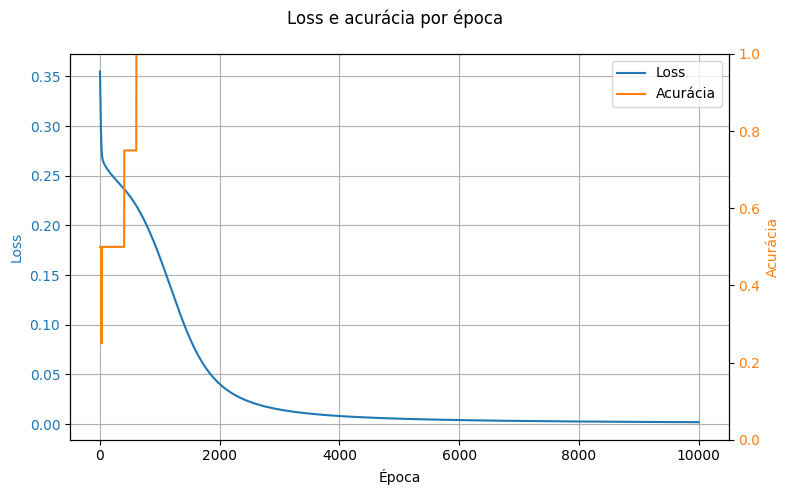

In [29]:
import matplotlib.pyplot as plt

epochs = np.arange(1, n_epochs + 1)
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(epochs, train_losses, color='tab:blue', label='Loss')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(epochs, train_accuracies, color='tab:orange', label='Acurácia')
ax2.set_ylabel('Acurácia', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax2.set_ylim(0, 1)

fig.suptitle('Loss e acurácia por época')
fig.tight_layout()
ax1.grid(True)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')
plt.show()


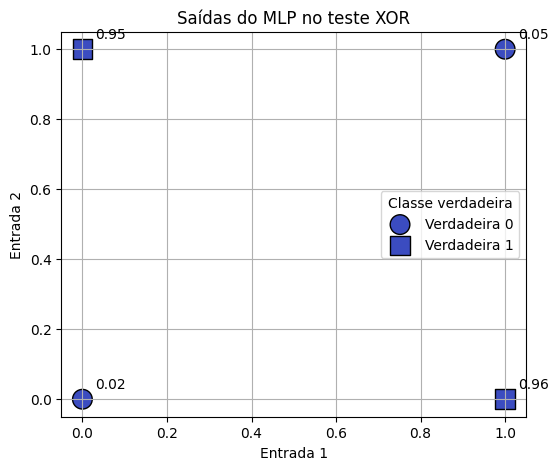

In [30]:
import matplotlib.pyplot as plt

# Visualizar as saídas previstas pelo MLP para o conjunto XOR
predictions = (A2 > 0.5).astype(int)

plt.figure(figsize=(6, 5))
for label, marker in [(0, 'o'), (1, 's')]:
    mask = (y.flatten() == label)
    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        c=predictions[mask].flatten(),
        cmap='coolwarm',
        marker=marker,
        s=200,
        edgecolors='k',
        label=f'Verdadeira {label}'
    )

for i in range(X.shape[0]):
    plt.text(
        X[i, 0] + 0.03,
        X[i, 1] + 0.03,
        f'{A2[i, 0]:.2f}',
        fontsize=10,
        color='black'
    )

plt.title('Saídas do MLP no teste XOR')
plt.xlabel('Entrada 1')
plt.ylabel('Entrada 2')
plt.legend(title='Classe verdadeira')
plt.grid(True)
plt.show()
